In [18]:
!pip install pillow pandas matplotlib openpyxl

Unable to create process using 'C:\Users\Amit D\anaconda3\python.exe "C:\Users\Amit D\anaconda3\Scripts\pip-script.py" install pillow pandas matplotlib openpyxl'


In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

In [20]:
# Loading dataset

df = pd.read_csv(r"C:\Amit Dubli\VS code\Assignment 5\ai_project_synthetic_datasets-20260505T155452Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\labels.csv")

print("First 5 rows:")
print(df.head())


First 5 rows:
                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal


In [21]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['filename', 'class'], dtype='object')


In [36]:
# Number of class and images per class

classes = df['class'].unique()

print("\nClasses Found:")
print(classes)

print("\nTotal Number of Classes:", len(classes))

class_counts = df['class'].value_counts()

print("\nImages per Class:")
print(class_counts)


Classes Found:
['normal' 'scratch' 'dent' 'stain']

Total Number of Classes: 4

Images per Class:
normal     120
scratch    120
dent       120
stain      120
Name: class, dtype: int64


In [29]:
## Image folder paths

base_path = r"C:\Amit Dubli\VS code\Assignment 5\ai_project_synthetic_datasets-20260505T155452Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"   


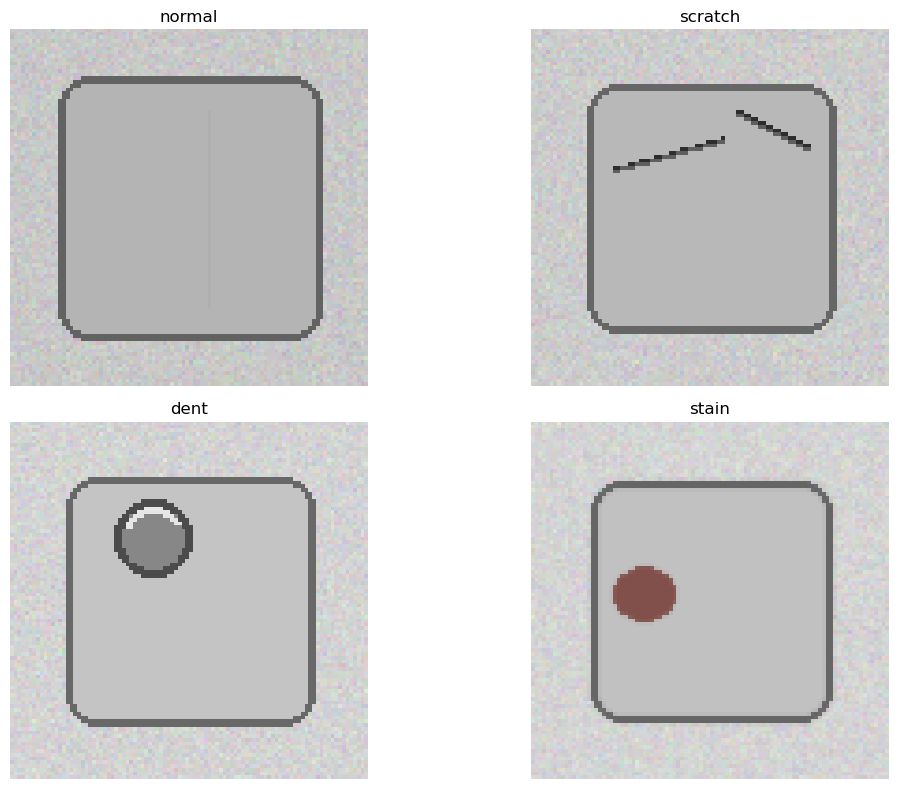

In [30]:
## Displaying sample images

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(base_path, class_name)

    image_files = os.listdir(class_folder)

    first_image = image_files[0]

    image_path = os.path.join(class_folder, first_image)

    img = Image.open(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
# Image dimension analysis

dimensions = []

for class_name in classes:

    class_folder = os.path.join(base_path, class_name)

    for image_file in os.listdir(class_folder):

        image_path = os.path.join(class_folder, image_file)

        try:

            img = Image.open(image_path)

            width, height = img.size

            channels = len(img.getbands())

            dimensions.append((width, height, channels))

        except Exception as e:

            print("Error reading:", image_file)

In [32]:
# Unique image dimensions

dimension_count = Counter(dimensions)

print("\nImage Dimensions Found:")

for dim, count in dimension_count.items():

    print(f"{dim} --> {count} images")


Image Dimensions Found:
(96, 96, 3) --> 480 images


In [37]:
# Checking dataset imbalance

max_images = class_counts.max()

min_images = class_counts.min()

print("\nDataset Balance Analysis:")

if max_images == min_images:

    print("Dataset is Balanced")

else:

    print("Dataset is Imbalanced")


Dataset Balance Analysis:
Dataset is Balanced


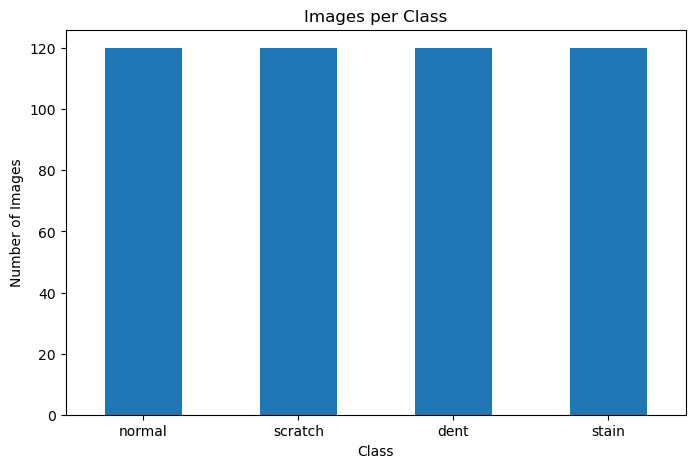

In [38]:
# Class distribution

plt.figure(figsize=(8,5))

class_counts.plot(kind='bar')

plt.title("Images per Class")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.show()

In [39]:
total_images = len(df)

print("\nTotal Number of Images:", total_images)



Total Number of Images: 480


In [40]:
print("\n========== DATASET SUMMARY ==========")

print(f"Total Classes: {len(classes)}")

print(f"Total Images: {total_images}")

print("\nClass Distribution:")

print(class_counts)

print("\nDataset Analysis Completed Successfully")


========== DATASET SUMMARY ==========
Total Classes: 4
Total Images: 480

Class Distribution:
normal     120
scratch    120
dent       120
stain      120
Name: class, dtype: int64

Dataset Analysis Completed Successfully


## Clearly explain why the selected problem type is appropriate for the dataset.

1. The dataset represents an Image Classification problem because each image is associated with one label among four classes - dent, scratch, normal, and stain. 
2. The goal of the model is to classify the entire image into one category based on visual features. Since there are no bounding boxes or pixel-level masks provided, object detection and segmentation techniques are not suitable. 
3. A CNN-based image classification model can be implemented using Python libraries such as TensorFlow or Keras to automatically learn image patterns and classify defects accurately.

In [41]:
# Installing required libraries
!pip install tensorflow pillow matplotlib scikit-learn

Unable to create process using 'C:\Users\Amit D\anaconda3\python.exe "C:\Users\Amit D\anaconda3\Scripts\pip-script.py" install tensorflow pillow matplotlib scikit-learn'


In [42]:
# Importing libraries

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [43]:
classes = ['dent', 'normal', 'scratch', 'stain']

In [44]:
IMG_SIZE = 128

In [45]:
images = []
labels = []

In [46]:
for class_index, class_name in enumerate(classes):

    class_folder = os.path.join(base_path, class_name)

    print(f"Loading images from: {class_folder}")

    for image_file in os.listdir(class_folder):

        image_path = os.path.join(class_folder, image_file)

        try:

            # Open image
            img = Image.open(image_path)

            # Convert to RGB
            img = img.convert("RGB")

            # Resize image
            img = img.resize((IMG_SIZE, IMG_SIZE))

            # Convert image to numpy array
            img_array = np.array(img)

            # Normalize pixel values
            img_array = img_array / 255.0

            # Store image and label
            images.append(img_array)

            labels.append(class_index)

        except Exception as e:

            print("Error loading:", image_file)

Loading images from: C:\Amit Dubli\VS code\Assignment 5\ai_project_synthetic_datasets-20260505T155452Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images\dent
Loading images from: C:\Amit Dubli\VS code\Assignment 5\ai_project_synthetic_datasets-20260505T155452Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images\normal
Loading images from: C:\Amit Dubli\VS code\Assignment 5\ai_project_synthetic_datasets-20260505T155452Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images\scratch
Loading images from: C:\Amit Dubli\VS code\Assignment 5\ai_project_synthetic_datasets-20260505T155452Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images\stain


In [47]:
# Creating to Numpy arrays

X = np.array(images)

y = np.array(labels)

print("\nImage Data Shape:", X.shape)

print("Label Shape:", y.shape)


Image Data Shape: (480, 128, 128, 3)
Label Shape: (480,)


In [48]:
y = to_categorical(y, num_classes=len(classes))

print("\nEncoded Label Shape:", y.shape)


Encoded Label Shape: (480, 4)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.2,
    
    random_state=42,
    
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


Training Data Shape: (384, 128, 128, 3)
Testing Data Shape: (96, 128, 128, 3)


In [50]:
datagen = ImageDataGenerator(

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.2,

    height_shift_range=0.2,

    horizontal_flip=True

)

# Fit augmentation generator
datagen.fit(X_train)

print("\nImage Augmentation Applied Successfully")


Image Augmentation Applied Successfully


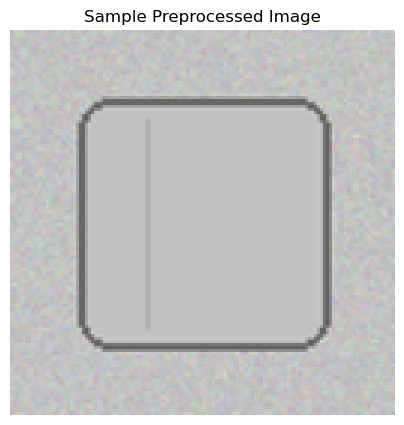

In [51]:
plt.figure(figsize=(5,5))

plt.imshow(X_train[0])

plt.title("Sample Preprocessed Image")

plt.axis("off")

plt.show()

In [52]:
print("\n========== PREPROCESSING SUMMARY ==========")

print(f"Image Size: {IMG_SIZE} x {IMG_SIZE}")

print("Pixel Values Normalized between 0 and 1")

print("Training and Testing Split Completed")

print("Image Augmentation Applied")

print("Dataset Ready for CNN Training")


========== PREPROCESSING SUMMARY ==========
Image Size: 128 x 128
Pixel Values Normalized between 0 and 1
Training and Testing Split Completed
Image Augmentation Applied
Dataset Ready for CNN Training


In [53]:
!pip install tensorflow

Unable to create process using 'C:\Users\Amit D\anaconda3\python.exe "C:\Users\Amit D\anaconda3\Scripts\pip-script.py" install tensorflow'


In [54]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
    
)

In [55]:
num_classes = 4

In [56]:
model = Sequential()

In [57]:
model.add(

    Conv2D(
        
        filters=32,
        
        kernel_size=(3,3),
        
        activation='relu',
        
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
)

In [58]:
model.add(

    MaxPooling2D(pool_size=(2,2))
)

In [59]:
model.add(

    Conv2D(
        
        filters=64,
        
        kernel_size=(3,3),
        
        activation='relu'
    )
)

In [60]:
model.add(

    MaxPooling2D(pool_size=(2,2))
)

In [61]:
model.add(

    Conv2D(
        
        filters=128,
        
        kernel_size=(3,3),
        
        activation='relu'
    )
)

In [62]:
model.add(

    MaxPooling2D(pool_size=(2,2))
)

In [63]:
model.add(

    Flatten()
)

In [64]:
model.add(

    Dense(
        
        128,
        
        activation='relu'
    )
)

In [65]:
model.add(

    Dropout(0.5)
)

In [66]:
model.add(

    Dense(
        
        num_classes,
        
        activation='softmax'
    )
)

In [67]:

model.compile(
    
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [68]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)       0

In [69]:
# Importing libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [70]:
# Training CNN model

history = model.fit(

    datagen.flow(X_train, y_train, batch_size=32),

    epochs=10,

    validation_data=(X_test, y_test)
)

Epoch 1/10
12/12 [==============================] - 9s 553ms/step - loss: 1.5065 - accuracy: 0.2422 - val_loss: 1.3853 - val_accuracy: 0.2500
Epoch 2/10
12/12 [==============================] - 6s 484ms/step - loss: 1.3875 - accuracy: 0.2604 - val_loss: 1.3854 - val_accuracy: 0.2500
Epoch 3/10
12/12 [==============================] - 6s 496ms/step - loss: 1.3861 - accuracy: 0.2786 - val_loss: 1.3835 - val_accuracy: 0.2500
Epoch 4/10
12/12 [==============================] - 6s 495ms/step - loss: 1.3872 - accuracy: 0.2396 - val_loss: 1.3816 - val_accuracy: 0.2500
Epoch 5/10
12/12 [==============================] - 6s 479ms/step - loss: 1.3844 - accuracy: 0.2109 - val_loss: 1.3758 - val_accuracy: 0.4896
Epoch 6/10
12/12 [==============================] - 6s 480ms/step - loss: 1.3699 - accuracy: 0.2969 - val_loss: 1.3069 - val_accuracy: 0.2500
Epoch 7/10
12/12 [==============================] - 6s 477ms/step - loss: 1.2942 - accuracy: 0.3828 - val_loss: 1.1828 - val_accuracy: 0.6250
Epoch 

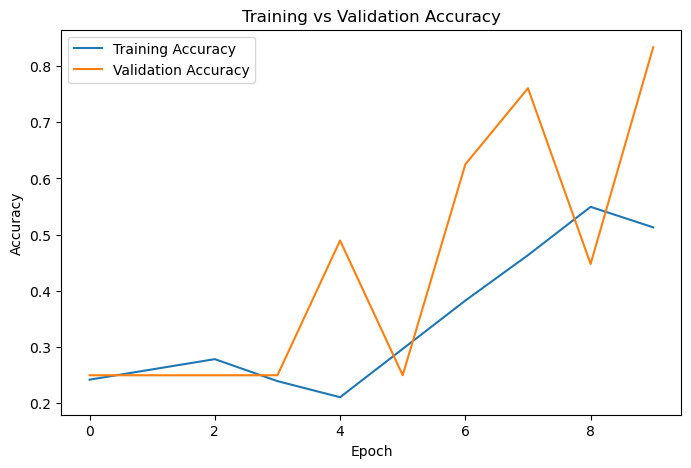

In [71]:
# Plotting training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

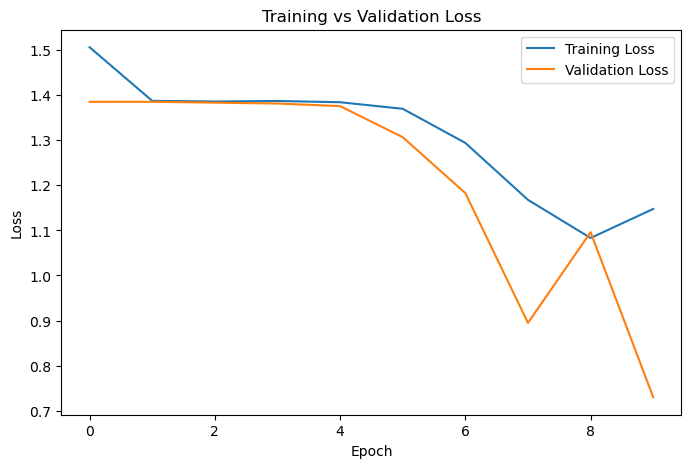

In [72]:
# Plotting training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [73]:
# Testing performance

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\n========== TEST PERFORMANCE ==========")

print(f"Test Loss: {test_loss:.4f}")

print(f"Test Accuracy: {test_accuracy:.4f}")

3/3 [==============================] - 0s 108ms/step - loss: 0.7298 - accuracy: 0.8333

========== TEST PERFORMANCE ==========
Test Loss: 0.7298
Test Accuracy: 0.8333


In [74]:
# Predictions

predictions = model.predict(X_test)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

3/3 [==============================] - 0s 106ms/step


<Figure size 800x600 with 0 Axes>

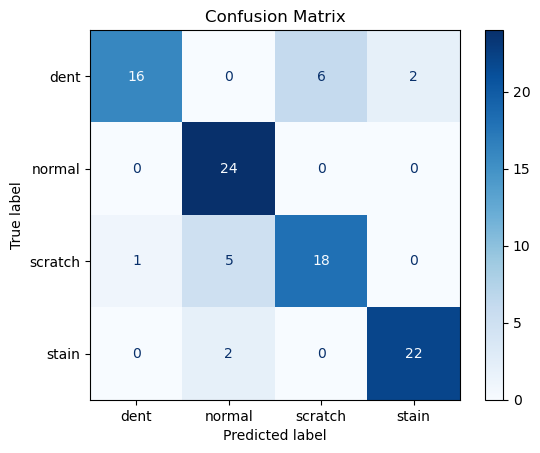

In [75]:
# Confusion matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    
    confusion_matrix=cm,
    
    display_labels=classes
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

In [76]:
# Classification report

print("\n========== CLASSIFICATION REPORT ==========")

print(

    classification_report(
        
        true_labels,
        
        predicted_labels,
        
        target_names=classes
    )
)


========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

        dent       0.94      0.67      0.78        24
      normal       0.77      1.00      0.87        24
     scratch       0.75      0.75      0.75        24
       stain       0.92      0.92      0.92        24

    accuracy                           0.83        96
   macro avg       0.85      0.83      0.83        96
weighted avg       0.85      0.83      0.83        96



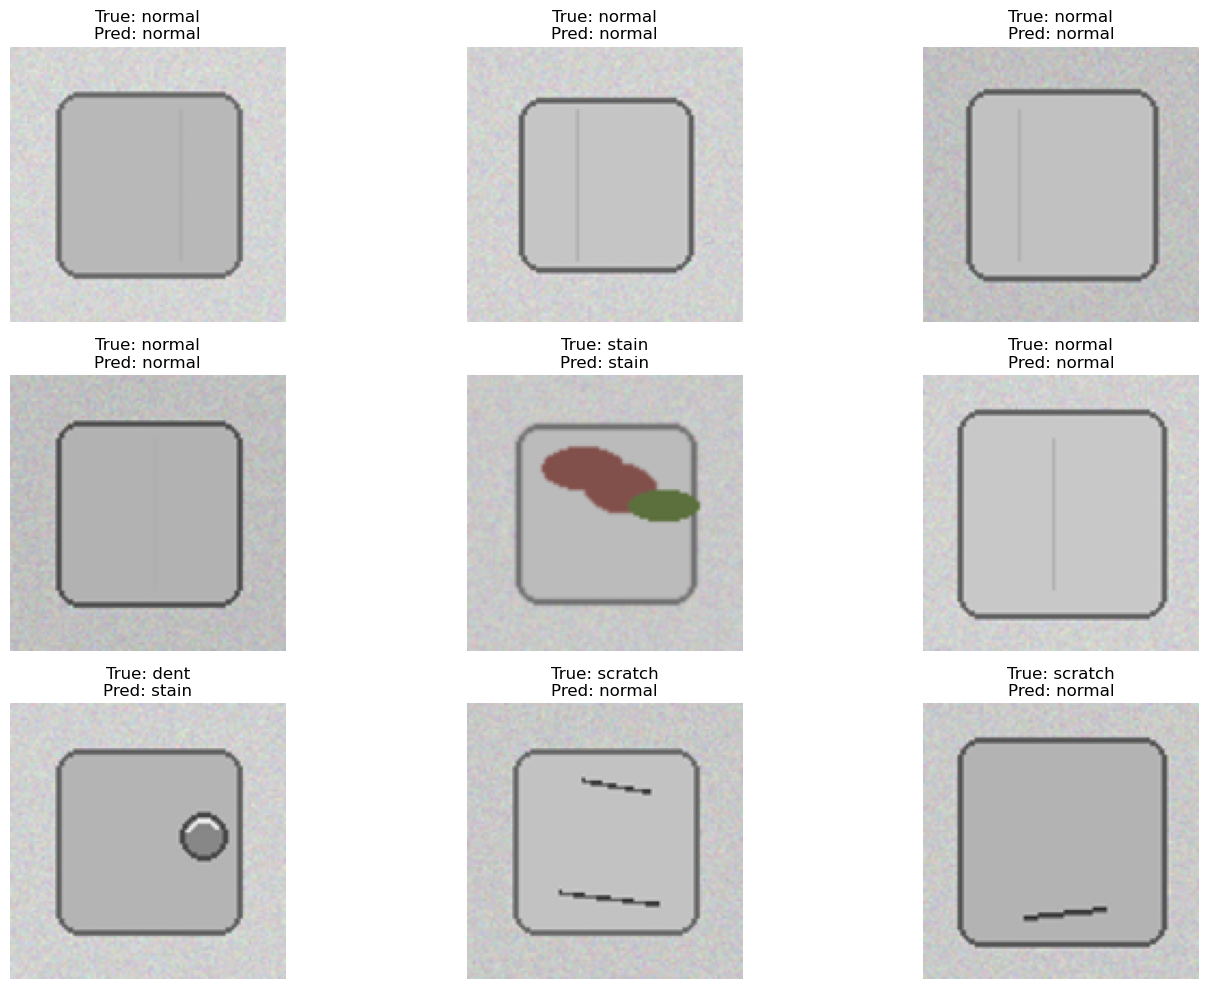

In [77]:
# Sample predictions

plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    true_class = classes[true_labels[i]]

    predicted_class = classes[predicted_labels[i]]

    plt.title(
        
        f"True: {true_class}\nPred: {predicted_class}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [78]:
# Training summary

final_train_acc = history.history['accuracy'][-1]

final_val_acc = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]

final_val_loss = history.history['val_loss'][-1]

print("\n========== FINAL RESULTS ==========")

print(f"Final Training Accuracy: {final_train_acc:.4f}")

print(f"Final Validation Accuracy: {final_val_acc:.4f}")

print(f"Final Training Loss: {final_train_loss:.4f}")

print(f"Final Validation Loss: {final_val_loss:.4f}")

print(f"Testing Accuracy: {test_accuracy:.4f}")

print("\nCNN Model Training and Evaluation Completed")


========== FINAL RESULTS ==========
Final Training Accuracy: 0.5130
Final Validation Accuracy: 0.8333
Final Training Loss: 1.1476
Final Validation Loss: 0.7298
Testing Accuracy: 0.8333

CNN Model Training and Evaluation Completed
